In [40]:
import pandas as pd

# Load the labeled data we created in Week 1
labeled_df = pd.read_csv("data/labeled_criteria.csv")

print(f"Total criteria: {len(labeled_df)}")
print(f"\nLabel distribution:")
print(labeled_df["label"].value_counts())
print(f"\nSample data:")
print(labeled_df.head(3))

Total criteria: 1340

Label distribution:
label
exclusion    736
inclusion    604
Name: count, dtype: int64

Sample data:
        nct_id                                          criterion      label
0  NCT01518517  Patient from 1 to 55 years old (Children and a...  inclusion
1  NCT01518517  Patients with 1st ALL relapse, which could be ...  inclusion
2  NCT01518517  Patient previously treated with free E.Coli L-...  inclusion


In [41]:
import re 

def clean_text(text):
    text = text.lower()  # Lowercase
    #text = re.sub(r'\d+', 'NUM', text) # Replace digits with 'NUM'
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

#cleaning 
labeled_df['clean_criterion'] = labeled_df['criterion'].apply(clean_text) # Apply text cleaning

#see the difference
print("BEFORE:", labeled_df['criterion'][0])
print("\nAFTER:", labeled_df['clean_criterion'][0])

BEFORE: Patient from 1 to 55 years old (Children and adolescents from 1 to 17 years/ Adults from 18 to 55 years)

AFTER: patient from 1 to 55 years old children and adolescents from 1 to 17 years adults from 18 to 55 years


In [42]:
from sklearn.model_selection import train_test_split

# Computers need numbers not words — 0 = inclusion, 1 = exclusion
labeled_df["label_num"] = labeled_df["label"].map({"inclusion": 0, "exclusion": 1})

# Split into training and testing sets
# 80% to train the model, 20% to test how well it learned
X_train, X_test, y_train, y_test = train_test_split(
    labeled_df["clean_criterion"],
    labeled_df["label_num"],
    test_size=0.2,
    random_state=42
)

print(f"Training examples: {len(X_train)}")
print(f"Testing examples: {len(X_test)}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())


Training examples: 1072
Testing examples: 268

Training label distribution:
label_num
1    590
0    482
Name: count, dtype: int64


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit_transform on training data = learn the vocabulary + convert
# transform on test data = convert using same vocabulary (no learning)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")
print(f"\nWhat this means:")
print(f"Each of your {X_train_tfidf.shape[0]} training criteria is now")
print(f"represented as {X_train_tfidf.shape[1]} numbers")

Training matrix shape: (1072, 5000)
Testing matrix shape: (268, 5000)

What this means:
Each of your 1072 training criteria is now
represented as 5000 numbers


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.87      0.71      0.78       122
           1       0.79      0.91      0.85       146

    accuracy                           0.82       268
   macro avg       0.83      0.81      0.82       268
weighted avg       0.83      0.82      0.82       268



In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n📊 {name}")
    print(classification_report(y_test, y_pred))


📊 Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       122
           1       0.83      0.87      0.85       146

    accuracy                           0.83       268
   macro avg       0.83      0.83      0.83       268
weighted avg       0.83      0.83      0.83       268


📊 Naive Bayes
              precision    recall  f1-score   support

           0       0.87      0.70      0.77       122
           1       0.78      0.91      0.84       146

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.81      0.81       268


📊 Random Forest
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       122
           1       0.78      0.91      0.84       146

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       

In [46]:
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(class_weight='balanced')

params = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear']
}

grid = GridSearchCV(model, params, cv=5, scoring='f1_macro', verbose=1)
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 10, 'solver': 'lbfgs'}
Best CV F1: 0.8496880394125945
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       122
           1       0.83      0.86      0.85       146

    accuracy                           0.83       268
   macro avg       0.83      0.83      0.83       268
weighted avg       0.83      0.83      0.83       268



In [47]:
import joblib 

joblib.dump(grid.best_estimator_, 'eligibility_classifier.pkl')

print("Model saved!")

Model saved!


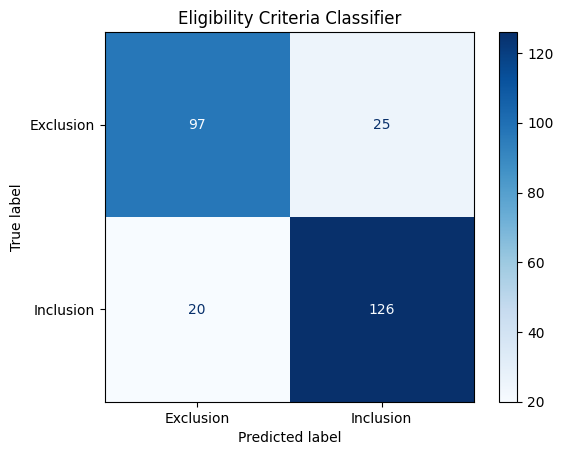

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)          # ✅ correct spelling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                        display_labels=['Exclusion', 'Inclusion'])
disp.plot(cmap='Blues')
plt.title('Eligibility Criteria Classifier')
plt.show()

In [49]:
import joblib

joblib.dump(grid.best_estimator_, 'eligibility_classifier.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model saved!")

Model saved!


In [50]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [51]:
def predict_criterion(text):
    vec = vectorizer.transform([text])
    pred = grid.best_estimator_.predict(vec)[0]
    label = "Inclusion" if pred == 1 else "Exclusion"
    return label

print(predict_criterion("Patients must be over 18 years old."))
print(predict_criterion("Patients with prior heart disease are excluded."))

Exclusion
Inclusion


In [52]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [53]:
def predict_criterion(text):
    vec = vectorizer.transform([text])
    pred = grid.best_estimator_.predict(vec)[0]
    proba = grid.best_estimator_.predict_proba(vec)[0]
    label = "Inclusion" if pred == 1 else "Exclusion"
    confidence =  round(max(proba)*100, 2)
    return f"{label} (Confidence: {confidence}%)"

tests = [
    "Patients must be over 18 years old.",
    "Patients with prior heart disease are excluded.",
    "Written informed consent obtained",
    "No history of allergic reaction to chemotherapy"
]

for t in tests:
    print(f"{t}")
    print(f"{predict_criterion(t)}\n")

Patients must be over 18 years old.
Exclusion (Confidence: 98.01%)

Patients with prior heart disease are excluded.
Inclusion (Confidence: 97.26%)

Written informed consent obtained
Exclusion (Confidence: 96.5%)

No history of allergic reaction to chemotherapy
Inclusion (Confidence: 90.33%)



In [54]:
print(labeled_df[['label', 'label_num']].drop_duplicates())
print("\nValue counts:")
print(labeled_df['label_num'].value_counts())

       label  label_num
0  inclusion          0
5  exclusion          1

Value counts:
label_num
1    736
0    604
Name: count, dtype: int64


In [55]:
def predict_criterion(text):
    vec = vectorizer.transform([text])
    pred = grid.best_estimator_.predict(vec)[0]
    proba = grid.best_estimator_.predict_proba(vec)[0]
    label = "Exclusion" if pred == 1 else "Inclusion"  # ← swapped
    confidence = round(max(proba) * 100, 2)
    return f"{label} (confidence: {confidence}%)"

In [56]:
# Try swapping the mapping
labeled_df['label_num'] = labeled_df['label'].map({'exclusion': 1, 'inclusion': 0})
print(labeled_df[['label', 'label_num']].drop_duplicates())

       label  label_num
0  inclusion          0
5  exclusion          1


In [57]:
def predict_criterion(text):
    vec = vectorizer.transform([text])
    pred = grid.best_estimator_.predict(vec)[0]
    proba = grid.best_estimator_.predict_proba(vec)[0]
    label = "Exclusion" if pred == 1 else "Inclusion"  # ← swapped
    confidence = round(max(proba) * 100, 2)
    return f"{label} (confidence: {confidence}%)"

In [58]:
def predict_criterion(text):
    vec = vectorizer.transform([text])
    pred = grid.best_estimator_.predict(vec)[0]
    proba = grid.best_estimator_.predict_proba(vec)[0]
    label = "Exclusion" if pred == 1 else "Inclusion"  # ← swapped
    confidence = round(max(proba) * 100, 2)
    return f"{label} (confidence: {confidence}%)"

# Test again
tests = [
    "Patient must be over 18 years old",
    "Patients with prior heart disease are excluded",
    "Written informed consent obtained",
    "No history of allergic reaction to chemotherapy"
]

for t in tests:
    print(f"📝 {t}")
    print(f"🔍 {predict_criterion(t)}\n")

📝 Patient must be over 18 years old
🔍 Inclusion (confidence: 96.59%)

📝 Patients with prior heart disease are excluded
🔍 Exclusion (confidence: 97.26%)

📝 Written informed consent obtained
🔍 Inclusion (confidence: 96.5%)

📝 No history of allergic reaction to chemotherapy
🔍 Exclusion (confidence: 90.33%)



In [59]:
import joblib

joblib.dump(grid.best_estimator_, 'eligibility_classifier.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("✅ Model saved!")

✅ Model saved!


In [60]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [61]:
import streamlit as st
import joblib

# Load saved model and vectorizer
model = joblib.load('eligibility_classifier.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

# App title
st.title("🏥 Clinical Trial Eligibility Classifier")
st.write("Enter a clinical trial criterion to classify it as Inclusion or Exclusion.")

# Input box
text = st.text_area("Enter criterion here:", height=100)

# Predict button
if st.button("🔍 Classify"):
    if text.strip() == "":
        st.warning("Please enter a criterion!")
    else:
        vec = vectorizer.transform([text])
        pred = model.predict(vec)[0]
        proba = model.predict_proba(vec)[0]
        label = "Exclusion" if pred == 1 else "Inclusion"
        confidence = round(max(proba) * 100, 2)

        if label == "Inclusion":
            st.success(f" {label} (Confidence: {confidence}%)")
        else:
            st.error(f" {label} (Confidence: {confidence}%)")

2026-05-09 12:40:52.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 12:40:52.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar